In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, RocCurveDisplay
from utils import get_data, confusion, print_final_results, final_test, plot_curves
from sklearn.exceptions import ConvergenceWarning
import warnings
import numpy as np

In [2]:
seed = 67
penalty = [None, 'l1', 'l2', 'elasticnet']
solvers = ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga', 'liblinear']
cs = [0.001, 0.01, 1, 1.001, 1.01, 1.1, 2, 5, 100]

In [3]:
def train_and_plot_learning_curves(
    models,
    wine_X_tr,
    wine_y_tr,
    wine_X_val,
    wine_y_val,
    seed: int,
    param_to_test: str,
    params: list[str],
    train_sizes: np.ndarray = np.linspace(0.1, 1.0, 15),
):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        warnings.simplefilter("ignore", category=UserWarning)
        warnings.simplefilter("ignore", category=FutureWarning)

        data_size = len(wine_X_tr)
        train_accuracies = []
        val_accuracies = []
        for model in models:
            train_acc_curve = []
            val_acc_curve = []
            np.random.seed(seed)
            for train_size in train_sizes:
                indices = np.random.choice(
                    data_size, int(train_size * data_size), replace=False
                )
                wine_X_tr_batch = wine_X_tr[indices]
                wine_y_tr_batch = wine_y_tr.iloc[indices]
                model.fit(wine_X_tr_batch, wine_y_tr_batch)
                train_acc_curve.append(
                    (train_size, model.score(wine_X_tr_batch, wine_y_tr_batch))
                )
                val_acc_curve.append((train_size, model.score(wine_X_val, wine_y_val)))
            train_accuracies.append(train_acc_curve)
            val_accuracies.append(val_acc_curve)

        param_value_str = params
        plot_curves(
            train_accuracies,
            param_value_str,
            "train_size",
            "training accuracy",
            param_to_test,
            f"train_{param_to_test}",
        )
        plot_curves(
            val_accuracies,
            param_value_str,
            "train_size",
            "validation accuracy",
            param_to_test,
            f"validation_{param_to_test}",
        )

In [4]:
def test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        warnings.simplefilter("ignore", category=UserWarning)
        warnings.simplefilter("ignore", category=FutureWarning)
        for solv in solvers:
            l1rat = 0
            for pen in penalty:
                match pen:
                    case 'elasticnet':
                        l1rat = 0.5
                    case 'l1':
                        l1rat = 1
                try:
                    max_c = 0
                    max_val_accuracy = 0
                    max_classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = 1, random_state = seed)
                    for c in cs:
                        classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = 100, C=c, l1_ratio=l1rat, random_state = seed);
                        classifier.fit(wine_X_tr, wine_y_tr);
                        if(100*accuracy_score(wine_y_val, classifier.predict(wine_X_val)) > max_val_accuracy):
                            max_val_accuracy = 100*accuracy_score(wine_y_val, classifier.predict(wine_X_val))
                            max_classifier = classifier 
                            max_c = c
                    print(f'Params: solver: {solv}, penalty: {pen}, C: {max_c}')
                    print(f'Training accuracy: {100*accuracy_score(wine_y_tr, max_classifier.predict(wine_X_tr)):.2f}%' )
                    print(f'Validation accuracy: {100*accuracy_score(wine_y_val, max_classifier.predict(wine_X_val)):.2f}%\n' )
                    
                except ValueError:
                    continue

In [5]:
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_data(seed)
test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

Params: solver: lbfgs, penalty: None, C: 0.001
Training accuracy: 54.97%
Validation accuracy: 55.38%

Params: solver: lbfgs, penalty: l2, C: 1.01
Training accuracy: 54.89%
Validation accuracy: 55.23%

Params: solver: newton-cg, penalty: None, C: 0.001
Training accuracy: 54.94%
Validation accuracy: 55.31%

Params: solver: newton-cg, penalty: l2, C: 100
Training accuracy: 54.94%
Validation accuracy: 55.31%

Params: solver: newton-cholesky, penalty: None, C: 0.001
Training accuracy: 54.94%
Validation accuracy: 55.31%

Params: solver: newton-cholesky, penalty: l2, C: 100
Training accuracy: 54.94%
Validation accuracy: 55.31%

Params: solver: sag, penalty: None, C: 0.001
Training accuracy: 54.94%
Validation accuracy: 55.31%

Params: solver: sag, penalty: l2, C: 100
Training accuracy: 54.94%
Validation accuracy: 55.31%

Params: solver: saga, penalty: None, C: 0.001
Training accuracy: 54.86%
Validation accuracy: 55.23%

Params: solver: saga, penalty: l1, C: 1
Training accuracy: 54.91%
Validati

In [6]:
classifier =  LogisticRegression(solver='liblinear', penalty='l1', max_iter = 100, random_state = seed, C=1)
confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)   

Results:
--- Accuracy (train): 54.79%
--- Accuracy (test): 56.08%


/Users/tanishasingh/Documents copy/UCI/UCI_Y2Quarter2/cs178Final/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [7]:
print_final_results(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val, wine_X_test, wine_y_test)
final_test(classifier, wine_X_test, wine_y_test)

/Users/tanishasingh/Documents copy/UCI/UCI_Y2Quarter2/cs178Final/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/Users/tanishasingh/Documents copy/UCI/UCI_Y2Quarter2/cs178Final/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Results:
--- Accuracy (train): 54.79%
--- Accuracy (validation): 56.08%
--- Accuracy (test): 53.08%


,accuracy,precision,recall,f1
0,0.530769,0.499708,0.530769,0.482876


In [8]:

models = [
    LogisticRegression(solver='lbfgs', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='lbfgs', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='newton-cg', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='newton-cg', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='newton-cholesky', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='newton-cholesky', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='sag', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='sag', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='saga', penalty='l1', max_iter = 100, random_state = seed),
    LogisticRegression(solver='saga', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.95, max_iter = 100, random_state = seed),
    LogisticRegression(solver='saga', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='liblinear', penalty='l1', max_iter = 100, random_state = seed),
    LogisticRegression(solver='liblinear', penalty='l2', max_iter = 100, random_state = seed),
    ]

train_sizes = np.linspace(0.1, 1.0, 15)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=UserWarning)
    warnings.simplefilter("ignore", category=FutureWarning)

    data_size = len(wine_X_tr)
    train_accuracies = []
    val_accuracies = []
    param_value_str = []
    for model in models:
        train_acc_curve = []
        val_acc_curve = []
        np.random.seed(seed)
        for train_size in train_sizes:
            indices = np.random.choice(
                data_size, int(train_size * data_size), replace=False
            )
            wine_X_tr_batch = wine_X_tr[indices]
            wine_y_tr_batch = wine_y_tr.iloc[indices]
            model.fit(wine_X_tr_batch, wine_y_tr_batch)
            train_acc_curve.append(
                (train_size, model.score(wine_X_tr_batch, wine_y_tr_batch))
            )
            val_acc_curve.append((train_size, model.score(wine_X_val, wine_y_val)))
        param_value_str.append(str(model.__getattribute__("solver")) + "-" + str(model.__getattribute__("penalty")))
        train_accuracies.append(train_acc_curve)
        val_accuracies.append(val_acc_curve)

    plot_curves(
        train_accuracies,
        param_value_str,
        "train_size",
        "training accuracy",
        "solver-and-penalty",
        f"train_{"solver-and-penalty"}",
    )
    plot_curves(
        val_accuracies,
        param_value_str,
        "train_size",
        "validation accuracy",
        "solver-and-penalty",
        f"validation_{"solver-and-penalty"}",
    )

In [9]:
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_data(seed, binary=True)
test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

Params: solver: lbfgs, penalty: None, C: 0.001
Training accuracy: 74.70%
Validation accuracy: 72.69%

Params: solver: lbfgs, penalty: l2, C: 0.01
Training accuracy: 73.93%
Validation accuracy: 73.15%

Params: solver: newton-cg, penalty: None, C: 0.001
Training accuracy: 74.67%
Validation accuracy: 72.69%

Params: solver: newton-cg, penalty: l2, C: 0.01
Training accuracy: 73.95%
Validation accuracy: 73.15%

Params: solver: newton-cholesky, penalty: None, C: 0.001
Training accuracy: 74.67%
Validation accuracy: 72.69%

Params: solver: newton-cholesky, penalty: l2, C: 0.01
Training accuracy: 73.95%
Validation accuracy: 73.15%

Params: solver: sag, penalty: None, C: 0.001
Training accuracy: 74.67%
Validation accuracy: 72.69%

Params: solver: sag, penalty: l2, C: 0.01
Training accuracy: 73.95%
Validation accuracy: 73.15%

Params: solver: saga, penalty: None, C: 0.001
Training accuracy: 74.67%
Validation accuracy: 72.69%

Params: solver: saga, penalty: l1, C: 1
Training accuracy: 74.75%
Valid

Results:
--- Accuracy (train): 73.72%
--- Accuracy (test): 72.77%


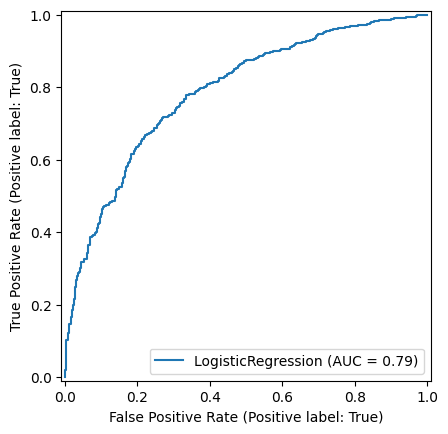

In [10]:
classifier =  LogisticRegression(solver='liblinear', penalty='l2', max_iter = 100, random_state = seed, C=0.01)
confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)
disp = RocCurveDisplay.from_estimator(classifier, wine_X_val, wine_y_val)

In [11]:
print_final_results(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val, wine_X_test, wine_y_test)
final_test(classifier, wine_X_test, wine_y_test)

Results:
--- Accuracy (train): 73.72%
--- Accuracy (validation): 72.77%
--- Accuracy (test): 73.46%


,accuracy,precision,recall,f1
0,0.734615,0.729836,0.734615,0.730414


In [12]:

models = [
    LogisticRegression(solver='lbfgs', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='lbfgs', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='newton-cg', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='newton-cg', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='newton-cholesky', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='newton-cholesky', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='sag', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='sag', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='saga', penalty='l1', max_iter = 100, random_state = seed),
    LogisticRegression(solver='saga', penalty='l2', max_iter = 100, random_state = seed),
    LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.95, max_iter = 100, random_state = seed),
    LogisticRegression(solver='saga', penalty=None, max_iter = 100, random_state = seed),

    LogisticRegression(solver='liblinear', penalty='l1', max_iter = 100, random_state = seed),
    LogisticRegression(solver='liblinear', penalty='l2', max_iter = 100, random_state = seed),
    ]

train_sizes = np.linspace(0.1, 1.0, 15)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=UserWarning)
    warnings.simplefilter("ignore", category=FutureWarning)

    data_size = len(wine_X_tr)
    train_accuracies = []
    val_accuracies = []
    param_value_str = []
    for model in models:
        train_acc_curve = []
        val_acc_curve = []
        np.random.seed(seed)
        for train_size in train_sizes:
            indices = np.random.choice(
                data_size, int(train_size * data_size), replace=False
            )
            wine_X_tr_batch = wine_X_tr[indices]
            wine_y_tr_batch = wine_y_tr.iloc[indices]
            model.fit(wine_X_tr_batch, wine_y_tr_batch)
            train_acc_curve.append(
                (train_size, model.score(wine_X_tr_batch, wine_y_tr_batch))
            )
            val_acc_curve.append((train_size, model.score(wine_X_val, wine_y_val)))
        param_value_str.append(str(model.__getattribute__("solver")) + "-" + str(model.__getattribute__("penalty")))
        train_accuracies.append(train_acc_curve)
        val_accuracies.append(val_acc_curve)

    plot_curves(
        train_accuracies,
        param_value_str,
        "train_size",
        "training accuracy",
        "solver-and-penalty",
        f"train_{"solver-and-penalty"}",
    )
    plot_curves(
        val_accuracies,
        param_value_str,
        "train_size",
        "validation accuracy",
        "solver-and-penalty",
        f"validation_{"solver-and-penalty"}",
    )